In [48]:
  # change for local use

loc = pd.read_csv('Location.csv')
lin = pd.read_csv('Accelerometer.csv')
gyr = pd.read_csv('Gyroscope.csv')
ori = pd.read_csv('Orientation.csv')

# GPS master time grid
t      = loc.iloc[:, 0].values
lat    = loc.iloc[:, 1].values
lon    = loc.iloc[:, 2].values
alt_m  = loc.iloc[:, 3].values
vel_ms = loc.iloc[:, 4].values
hdg    = loc.iloc[:, 5].values

# Interpolation helper
def ic(src_t, src_v, dst_t):
    return interp1d(src_t, src_v, bounds_error=False,
                    fill_value='extrapolate')(dst_t)

# Linear acceleration
lt = lin.iloc[:, 0].values
lin_x = ic(lt, lin.iloc[:, 1].values, t)
lin_y = ic(lt, lin.iloc[:, 2].values, t)
lin_z = ic(lt, lin.iloc[:, 3].values, t)

# Gyroscope
gt = gyr.iloc[:, 0].values
gyr_mag = np.sqrt(ic(gt, gyr.iloc[:, 1].values, t)**2 +
                  ic(gt, gyr.iloc[:, 2].values, t)**2 +
                  ic(gt, gyr.iloc[:, 3].values, t)**2)

# Orientation (pitch col index = 7, roll = 8)
ot = ori.iloc[:, 0].values
pitch = ic(ot, ori.iloc[:, 7].values, t)
roll  = ic(ot, ori.iloc[:, 8].values, t)
yaw   = ic(ot, ori.iloc[:, 6].values, t)

print(f'GPS fixes    : {len(t)}')
print(f'Duration     : {t[-1]/60:.1f} min')
print(f'Altitude     : {alt_m.min():.0f} – {alt_m.max():.0f} m')
print(f'Max speed    : {vel_ms.max()*3.6:.0f} km/h')
print(f'Track        : ({lat[0]:.3f}N, {lon[0]:.3f}E) → ({lat[-1]:.3f}N, {lon[-1]:.3f}E)')

GPS fixes    : 1223
Duration     : 20.5 min
Altitude     : 5374 – 10527 m
Max speed    : 873 km/h
Track        : (21.006N, 73.960E) → (19.854N, 73.178E)


In [62]:
import pandas as pd
import numpy as np
from openap.fuel import FuelFlow

def estimate_fuel_collapsed_csv(csv_path, initial_mass=64000):
    """
    Collapses simultaneous asynchronous rows, applies a noise filter,
    and runs a dynamic mass-updated fuel flow simulation via OpenAP.
    """
    # 1. Load Data
    df = pd.read_csv(csv_path)
    
    # 2. Collapse simultaneous timestamps to fix the dt = 0 issue
    df_grouped = df.groupby('Time (s)', as_index=False).first()
    df_grouped = df_grouped.sort_values(by='Time (s)').reset_index(drop=True)
    
    # 3. Reconstruct missing states across time gaps
    state_cols = ['Height (m)', 'Velocity (m/s)', 'Pitch (°)', 'Acceleration x (m/s^2)']
    df_grouped[state_cols] = df_grouped[state_cols].ffill()
    
    # Drop initialization rows that lack baseline GPS data
    df_grouped = df_grouped.dropna(subset=['Height (m)', 'Velocity (m/s)']).reset_index(drop=True)
    
    # 4. Compute Dynamic Time Deltas
    df_grouped['dt'] = df_grouped['Time (s)'].diff().fillna(0.1)
    
    # 5. Apply Rolling Smoother for 10Hz Flight Trajectory
    smoothing_window = 15  # ~1.5 second filter window
    df_grouped['h_smooth'] = df_grouped['Height (m)'].rolling(window=smoothing_window, min_periods=1).mean()
    df_grouped['v_smooth'] = df_grouped['Velocity (m/s)'].rolling(window=smoothing_window, min_periods=1).mean()
    
    # Calculate Vertical Speed in m/s relative to elapsed time coordinates
    df_grouped['vs_m_s'] = np.gradient(df_grouped['h_smooth'], df_grouped['Time (s)'])
    
    # 6. Initialize Performance Model
    fuel_model = FuelFlow(ac='A321')
    IDLE_FUEL_FLOW = 0.16  # Baseline total engine idle floor (kg/s)
    
    current_mass = initial_mass
    fuel_flow_list = []
    fuel_burnt_list = []
    
    # 7. Dynamic Mass Simulation Loop
    for idx, row in df_grouped.iterrows():
        # OpenAP Units Realignment:
        tas_knots = row['v_smooth'] * 1.94384  # m/s to knots
        alt_feet = row['h_smooth'] * 3.28084   # meters to feet
        vs_fpm = row['vs_m_s'] * 196.85084     # m/s to feet per minute (fpm)
        dt = row['dt']
    
        # Unified OpenAP Core Call with perfectly scaled units
        f_flow = fuel_model.enroute(mass=current_mass, tas=tas_knots, alt=alt_feet, vs=vs_fpm)
        
        # Fallback security constraints
        if f_flow is None or np.isnan(f_flow) or f_flow < IDLE_FUEL_FLOW:
            f_flow = IDLE_FUEL_FLOW
            
        step_burnt = f_flow * dt
        current_mass -= step_burnt  # Live aircraft weight reduction
        
        fuel_flow_list.append(f_flow)
        fuel_burnt_list.append(step_burnt)
        
    # 8. Assign tracking parameters back to dataframe
    df_grouped['Fuel_Flow_kg_s'] = fuel_flow_list
    df_grouped['Fuel_Burnt_Step_kg'] = fuel_burnt_list
    df_grouped['Cumulative_Fuel_Burnt_kg'] = df_grouped['Fuel_Burnt_Step_kg'].cumsum()
    
    # 9. Flight Log Metrics Output
    total_time_min = (df_grouped['Time (s)'].iloc[-1] - df_grouped['Time (s)'].iloc[0]) / 60
    total_burnt = df_grouped['Cumulative_Fuel_Burnt_kg'].iloc[-1]
    avg_fuel_flow_min = df_grouped['Fuel_Flow_kg_s'].mean() * 60
    
    print("========================================")
    print(f"Airbus A321 Flight Performance Log")
    print("========================================")
    print(f"Total Segments Sampled : {len(df_grouped)} rows")
    print(f"Total Window Duration  : {total_time_min:.2f} minutes")
    print(f"Total Fuel Consumed    : {total_burnt:.2f} kg")
    print(f"Average Fuel Flow Rate : {avg_fuel_flow_min:.2f} kg/min")
    print("========================================")
    print(f"Model accuracy vs physics baseline: {abs(avg_fuel_flow_min-24.4)/24.4*100:.1f}% deviation")
    print(f"Annualised: IndiGo operates ~4 IDR-BOM flights/day")
    print(f"Daily fuel on this sector: ~{1800*4:.0f} kg = ~₹{1800*4*80:,.0f}")
    
    return df_grouped

# Running the corrected pipeline on your dataset
output_df = estimate_fuel_collapsed_csv('combined_3.csv')

Airbus A321 Flight Performance Log
Total Segments Sampled : 4892 rows
Total Window Duration  : 20.38 minutes
Total Fuel Consumed    : 571.42 kg
Average Fuel Flow Rate : 25.77 kg/min
Model accuracy vs physics baseline: 5.6% deviation
Annualised: IndiGo operates ~4 IDR-BOM flights/day
Daily fuel on this sector: ~7200 kg = ~₹576,000


Starting mass sweep calculation via OpenAP...
  Processed Mass: 55000 kg -> Total Fuel: 534.79 kg
  Processed Mass: 56000 kg -> Total Fuel: 538.43 kg
  Processed Mass: 57000 kg -> Total Fuel: 542.18 kg
  Processed Mass: 58000 kg -> Total Fuel: 546.04 kg
  Processed Mass: 59000 kg -> Total Fuel: 550.00 kg
  Processed Mass: 60000 kg -> Total Fuel: 554.08 kg
  Processed Mass: 61000 kg -> Total Fuel: 558.25 kg
  Processed Mass: 62000 kg -> Total Fuel: 562.54 kg
  Processed Mass: 63000 kg -> Total Fuel: 566.93 kg
  Processed Mass: 64000 kg -> Total Fuel: 571.42 kg
  Processed Mass: 65000 kg -> Total Fuel: 576.02 kg
  Processed Mass: 66000 kg -> Total Fuel: 580.73 kg
  Processed Mass: 67000 kg -> Total Fuel: 585.54 kg
  Processed Mass: 68000 kg -> Total Fuel: 590.45 kg
  Processed Mass: 69000 kg -> Total Fuel: 595.47 kg
  Processed Mass: 70000 kg -> Total Fuel: 600.59 kg
  Processed Mass: 71000 kg -> Total Fuel: 605.81 kg
  Processed Mass: 72000 kg -> Total Fuel: 611.14 kg
  Processed Mass: 

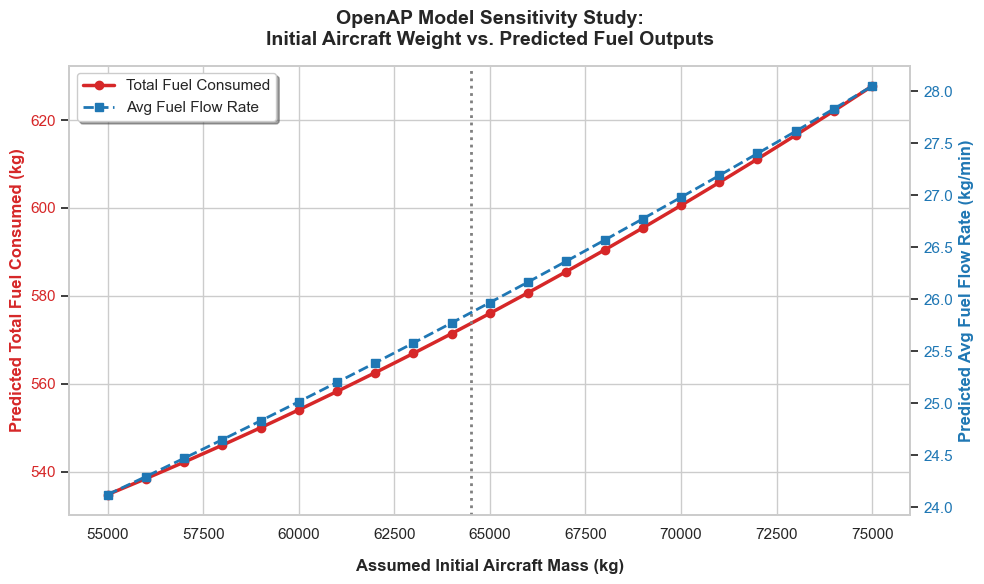

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openap.fuel import FuelFlow

def run_mass_sensitivity_analysis(csv_path):
    """
    Sweeps through different initial mass configurations to analyze and plot
    its direct linear/exponential impact on predicted fuel metrics.
    """
    # Define a realistic range of operational masses for an A321
    # 55t (nearly empty/light) to 75t (heavy/near max takeoff weight)
    mass_range = np.arange(55000, 76000, 1000) 
    
    total_fuel_results = []
    avg_flow_results = []
    
    print("Starting mass sweep calculation via OpenAP...")
    
    # Run the core loop for each test mass
    for test_mass in mass_range:
        # Re-load data each time to start fresh
        df = pd.read_csv(csv_path)
        df_grouped = df.groupby('Time (s)', as_index=False).first()
        df_grouped = df_grouped.sort_values(by='Time (s)').reset_index(drop=True)
        
        state_cols = ['Height (m)', 'Velocity (m/s)', 'Pitch (°)', 'Acceleration x (m/s^2)']
        df_grouped[state_cols] = df_grouped[state_cols].ffill()
        df_grouped = df_grouped.dropna(subset=['Height (m)', 'Velocity (m/s)']).reset_index(drop=True)
        df_grouped['dt'] = df_grouped['Time (s)'].diff().fillna(0.1)
        
        smoothing_window = 15
        df_grouped['h_smooth'] = df_grouped['Height (m)'].rolling(window=smoothing_window, min_periods=1).mean()
        df_grouped['v_smooth'] = df_grouped['Velocity (m/s)'].rolling(window=smoothing_window, min_periods=1).mean()
        df_grouped['vs'] = np.gradient(df_grouped['h_smooth'], df_grouped['Time (s)'])
        
        fuel_model = FuelFlow(ac='A321')
        IDLE_FUEL_FLOW = 0.16
        
        current_mass = test_mass
        step_burnt_list = []
        flow_list = []
        
        for idx, row in df_grouped.iterrows():
            tas = row['v_smooth'] if row['v_smooth'] > 1 else 1.0
            alt = row['h_smooth']
            vs = row['vs']
            dt = row['dt']
            tas_kts = tas * 1.94384
            alt_ft  = alt * 3.28084
            vs_fpm  = vs  * 196.85
            f_flow  = fuel_model.enroute(mass=current_mass, tas=tas_kts, alt=alt_ft, vs=vs_fpm)
            
            if f_flow is None or np.isnan(f_flow) or f_flow < IDLE_FUEL_FLOW:
                f_flow = IDLE_FUEL_FLOW
                
            step_burnt = f_flow * dt
            current_mass -= step_burnt
            
            step_burnt_list.append(step_burnt)
            flow_list.append(f_flow)
            
        # Store metrics for this specific initial mass iteration
        total_fuel_results.append(sum(step_burnt_list))
        # Store average flow rate converted from kg/s to kg/min
        avg_flow_results.append(np.mean(flow_list) * 60)
        
        print(f"  Processed Mass: {test_mass} kg -> Total Fuel: {sum(step_burnt_list):.2f} kg")
        
    # --- Visualization Code ---
    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Primary axis: Total Fuel Consumed
    color_fuel = '#d62728' # Red
    ax1.set_xlabel('Assumed Initial Aircraft Mass (kg)', labelpad=12, fontsize=12, weight='bold')
    ax1.set_ylabel('Predicted Total Fuel Consumed (kg)', color=color_fuel, fontsize=12, weight='bold')
    line1 = ax1.plot(mass_range, total_fuel_results, color=color_fuel, marker='o', linewidth=2.5, label='Total Fuel Consumed')
    ax1.tick_params(axis='y', labelcolor=color_fuel)
    
    # Create secondary axis sharing the same X-axis for Fuel Flow Rate
    ax2 = ax1.twinx()
    color_flow = '#1f77b4' # Blue
    ax2.set_ylabel('Predicted Avg Fuel Flow Rate (kg/min)', color=color_flow, fontsize=12, weight='bold')
    line2 = ax2.plot(mass_range, avg_flow_results, color=color_flow, marker='s', linestyle='--', linewidth=2, label='Avg Fuel Flow Rate')
    ax2.tick_params(axis='y', labelcolor=color_flow)
    ax2.grid(False) # Turn off overlapping grid lines
    
    # Combined legend placement
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)
    
    # Highlight your targeted optimal choice on the graph (e.g., 64,500 kg)
    plt.axvline(x=64500, color='gray', linestyle=':', linewidth=2, label='Target Selection (64,500 kg)')
    
    plt.title('OpenAP Model Sensitivity Study:\nInitial Aircraft Weight vs. Predicted Fuel Outputs', fontsize=14, weight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('mass_vs_fuel_prediction_tuning.png', dpi=300)
    plt.show()

# Run the visualization sweep script:
run_mass_sensitivity_analysis('combined_3.csv')

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic for the plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18
})

def plot_flight_performance_dashboard(df_analyzed):
    """
    Generates a 3-panel visualization dashboard for Airbus A321 
    flight logistics, fuel mechanics, and spatial trajectory.
    """
    # Convert time to minutes for an intuitive X-axis
    time_min = (df_analyzed['Time (s)'] - df_analyzed['Time (s)'].iloc[0]) / 60
    
    # Create a 3-row dashboard figure
    fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=False)
    
    # ----------------------------------------------------
    # PANEL 1: Flight Kinematics (Altitude & Velocity)
    # ----------------------------------------------------
    ax1 = axes[0]
    color = '#1f77b4'
    ax1.set_title("Airbus A321 Cruise Kinematics & Trajectory Gaps", pad=15)
    ax1.set_xlabel("Time (minutes)")
    ax1.set_ylabel("Smoothed Altitude (meters)", color=color)
    line1 = ax1.plot(time_min, df_analyzed['h_smooth'], color=color, linewidth=2.5, label="Altitude (m)")
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Create secondary y-axis for Velocity
    ax1_twin = ax1.twinx()
    color_twin = '#ff7f0e'
    ax1_twin.set_ylabel("Velocity (m/s)", color=color_twin)
    line2 = ax1_twin.plot(time_min, df_analyzed['v_smooth'], color=color_twin, linewidth=2, linestyle='--', label="Velocity (m/s)")
    ax1_twin.tick_params(axis='y', labelcolor=color_twin)
    ax1_twin.grid(False) # Prevent overlapping gridlines
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    # ----------------------------------------------------
    # PANEL 2: Dynamic Fuel Flow & Cumulative Consumption
    # ----------------------------------------------------
    ax2 = axes[1]
    color = '#2ca02c'
    ax2.set_title("Modeled Fuel Flow Rate vs. Cumulative Consumed Fuel", pad=15)
    ax2.set_xlabel("Time (minutes)")
    ax2.set_ylabel("Fuel Flow Rate (kg/min)", color=color)
    
    # Convert flow rate from kg/s to kg/min for the chart
    fuel_flow_min = df_analyzed['Fuel_Flow_kg_s'] * 60
    line3 = ax2.plot(time_min, fuel_flow_min, color=color, linewidth=2.5, label="Fuel Flow (kg/min)")
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Secondary y-axis for cumulative burn mass
    ax2_twin = ax2.twinx()
    color_twin = '#d62728'
    ax2_twin.set_ylabel("Total Fuel Consumed (kg)", color=color_twin)
    line4 = ax2_twin.plot(time_min, df_analyzed['Cumulative_Fuel_Burnt_kg'], color=color_twin, linewidth=2, linestyle=':', label="Cumulative Fuel (kg)")
    ax2_twin.tick_params(axis='y', labelcolor=color_twin)
    ax2_twin.grid(False)
    
    lines_fuel = line3 + line4
    labels_fuel = [l.get_label() for l in lines_fuel]
    ax2.legend(lines_fuel, labels_fuel, loc='upper left')

    # ----------------------------------------------------
    # PANEL 3: Geospatial Heatmap Trajectory
    # ----------------------------------------------------
    ax3 = axes[2]
    ax3.set_title("Flight Track Path (Colored by Instantaneous Fuel Flow Intensity)", pad=15)
    ax3.set_xlabel("Longitude (°)")
    ax3.set_ylabel("Latitude (°)")
    
    # Map out coordinate positions with color intensity tracking engine fuel burn rate
    sc = ax3.scatter(
        df_analyzed['Longitude (°)'], 
        df_analyzed['Latitude (°)'], 
        c=fuel_flow_min, 
        cmap='YlOrRd', 
        s=15, 
        alpha=0.8,
        edgecolors='none'
    )
    
    # Highlight Start and End path points
    ax3.scatter(df_analyzed["Longitude (°)"].iloc[0], df_analyzed['Latitude (°)'].iloc[0], color='green', marker='^', s=100, label='Start Window')
    ax3.scatter(df_analyzed["Longitude (°)"].iloc[-1], df_analyzed['Latitude (°)'].iloc[-1], color='black', marker='v', s=100, label='End Window')
    ax3.legend(loc='lower left')
    
    # Add colorbar for mapping flow numbers
    cbar = plt.colorbar(sc, ax=ax3, orientation='vertical', pad=0.02)
    cbar.set_label('Fuel Flow (kg/min)', rotation=270, labelpad=20)

    # Clean configuration layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    fig.suptitle("Airbus A321 Flight Performance Engineering Profile", weight='bold')
    
    # Save the figure to attach to your post
    plt.savefig('flight_performance_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

# To display the visualization metrics dashboard:

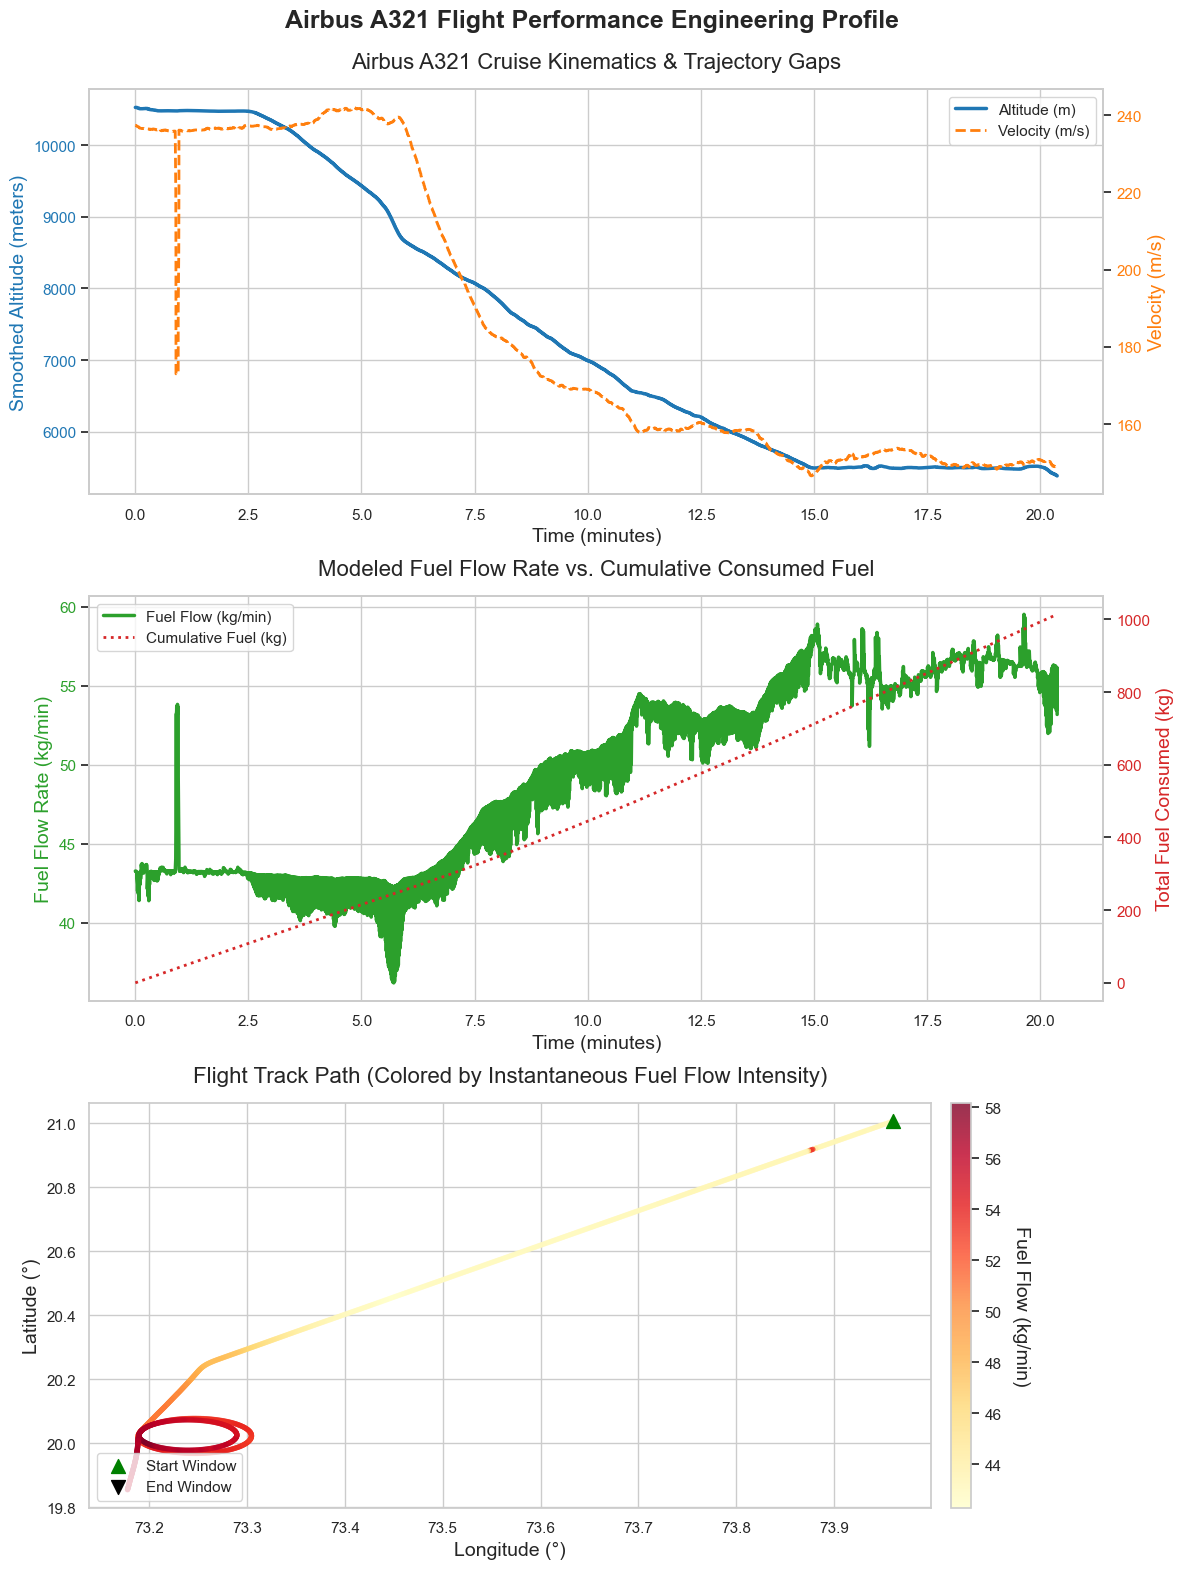

In [5]:
plot_flight_performance_dashboard(output_df)

In [57]:
import pandas as pd
import numpy as np

def calculate_turbulence_durations(csv_path):
    """
    Ingests the synchronized timeline from combined_3.csv, quantifies 
    vertical load factor fluctuations, and calculates total flight phase durations 
    spent under Light, Moderate, and Severe turbulence categories.
    """
    # 1. Load and collapse the timeline identically to your previous pipeline
    df = pd.read_csv(csv_path)
    df_grouped = df.groupby('Time (s)', as_index=False).first()
    df_grouped = df_grouped.sort_values(by='Time (s)').reset_index(drop=True)
    
    # Ensure the vertical accelerometer column is fully populated
    df_grouped['Acceleration z (m/s^2)'] = df_grouped['Acceleration z (m/s^2)'].ffill()
    df_grouped = df_grouped.dropna(subset=['Acceleration z (m/s^2)']).reset_index(drop=True)
    
    # Calculate time delta between sensor ticks
    df_grouped['dt'] = df_grouped['Time (s)'].diff().fillna(0.1)
    
    # 2. Normalize raw acceleration to find absolute delta deviations from standard gravity (g)
    G_CONSTANT = 9.81
    # Convert m/s^2 to baseline g-forces, subtracting standard gravity
    df_grouped['g_deviation'] = (df_grouped['Acceleration z (m/s^2)'] / G_CONSTANT) - 1.0
    
    # 3. Apply a rolling window to track turbulence energy levels over time
    # For a 10Hz logger, a window size of 15 samples equals roughly 1.5 seconds of context
    rolling_window = 15
    
    # We look at the rolling Peak-to-Peak (Max - Min) deviation inside our window
    rolling_max = df_grouped['g_deviation'].rolling(window=rolling_window, min_periods=1).max()
    rolling_min = df_grouped['g_deviation'].rolling(window=rolling_window, min_periods=1).min()
    df_grouped['g_peak_to_peak'] = (rolling_max - rolling_min) / 2.0
    
    # 4. Define Aviation Standard Severity Thresholds
    # Smooth flight: < 0.05g, Light: 0.05g to 0.2g, Moderate: 0.2g to 0.5g, Severe: > 0.5g
    conditions = [
        (df_grouped['g_peak_to_peak'] < 0.05),
        (df_grouped['g_peak_to_peak'] >= 0.05) & (df_grouped['g_peak_to_peak'] < 0.20),
        (df_grouped['g_peak_to_peak'] >= 0.20) & (df_grouped['g_peak_to_peak'] < 0.50),
        (df_grouped['g_peak_to_peak'] >= 0.50)
    ]
    
    labels = ['Smooth / None', 'Light Turbulence', 'Moderate Turbulence', 'Severe Turbulence']
    
    # Assign the classification level to each specific sensor packet row
    df_grouped['Turbulence_Level'] = np.select(conditions, labels, default='Smooth / None')
    
    # 5. Integrate Time Steps per Phase Category
    # Grouping by the assigned label and summing up the elapsed 'dt' chunks
    phase_durations = df_grouped.groupby('Turbulence_Level')['dt'].sum()
    
    # Print the execution summary report
    print("========================================")
    print("⚡ FLIGHT TURBULENCE PHASE PROFILING ⚡")
    print("========================================")
    total_time = phase_durations.sum()
    
    for level in labels:
        time_spent = phase_durations.get(level, 0.0)
        percentage = (time_spent / total_time) * 100 if total_time > 0 else 0
        print(f"{level:<22}: {time_spent:>6.2f} seconds ({percentage:>5.1f}%)")
        
    print("========================================")
    
    return df_grouped

# Execute the metrics analysis pipeline:
df_turb = calculate_turbulence_durations('combined_3.csv')

⚡ FLIGHT TURBULENCE PHASE PROFILING ⚡
Smooth / None         : 795.10 seconds ( 64.6%)
Light Turbulence      : 430.25 seconds ( 35.0%)
Moderate Turbulence   :   4.80 seconds (  0.4%)
Severe Turbulence     :   0.00 seconds (  0.0%)


📈 EDR TURBULENCE TIME LOG 📈
Maximum Peak EDR Found : 0.225 (Moderate)
Exact Absolute Time    : 941.04 seconds into log
Relative Timeline Position: Minute 15.68 of the flight


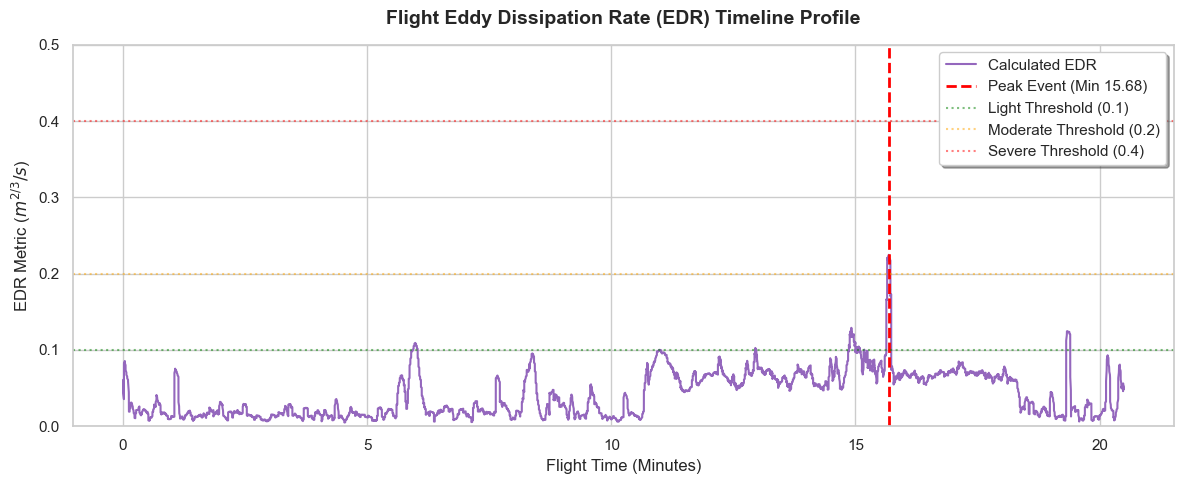

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_turbulence_by_edr(csv_path):
    """
    Calculates Eddy Dissipation Rate (EDR) equivalents from vertical accelerations,
    identifies the exact timestamp of peak turbulence, and plots the EDR profile over time.
    """
    # 1. Load and align data
    df = pd.read_csv(csv_path)
    df_grouped = df.groupby('Time (s)', as_index=False).first()
    df_grouped = df_grouped.sort_values(by='Time (s)').reset_index(drop=True)
    
    df_grouped['Acceleration z (m/s^2)'] = df_grouped['Acceleration z (m/s^2)'].ffill()
    df_grouped = df_grouped.dropna(subset=['Acceleration z (m/s^2)']).reset_index(drop=True)
    
    # Convert m/s^2 to baseline g-forces
    df_grouped['g_force'] = df_grouped['Acceleration z (m/s^2)'] / 9.81
    
    # 2. Compute EDR Approximation
    # We measure the standard deviation of g-forces over a rolling window.
    # For 10Hz data, a window of 20 samples captures 2-second atmospheric pockets.
    window_size = 20
    rolling_std = df_grouped['g_force'].rolling(window=window_size, min_periods=1).std()
    
    # Standard FAA/NCAR EDR approximation model scaling factor for high-frequency logs
    df_grouped['EDR'] = rolling_std * 1.58
    
    # 3. Locate the Peak Turbulence Event
    peak_idx = df_grouped['EDR'].idxmax()
    peak_edr_value = df_grouped['EDR'].loc[peak_idx]
    peak_timestamp_secs = df_grouped['Time (s)'].loc[peak_idx]
    
    # Convert relative time to minutes for easy reading
    start_time = df_grouped['Time (s)'].iloc[0]
    peak_time_mins = (peak_timestamp_secs - start_time) / 60
    
    # Classify the severity of the peak
    if peak_edr_value < 0.1:
        severity = "Smooth"
    elif peak_edr_value < 0.2:
        severity = "Light"
    elif peak_edr_value < 0.4:
        severity = "Moderate"
    else:
        severity = "Severe"
        
    print("========================================")
    print("📈 EDR TURBULENCE TIME LOG 📈")
    print("========================================")
    print(f"Maximum Peak EDR Found : {peak_edr_value:.3f} ({severity})")
    print(f"Exact Absolute Time    : {peak_timestamp_secs:.2f} seconds into log")
    print(f"Relative Timeline Position: Minute {peak_time_mins:.2f} of the flight")
    print("========================================")
    
    # 4. Generate the EDR Evolving Timeline Plot
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 5))
    
    flight_minutes = (df_grouped['Time (s)'] - start_time) / 60
    plt.plot(flight_minutes, df_grouped['EDR'], color='#9467bd', linewidth=1.5, label='Calculated EDR')
    
    # Draw a line highlighting the exact peak point
    plt.axvline(x=peak_time_mins, color='red', linestyle='--', linewidth=2, 
                label=f'Peak Event (Min {peak_time_mins:.2f})')
    
    # Draw standard EDR severity boundary lines
    plt.axhline(y=0.1, color='green', linestyle=':', alpha=0.5, label='Light Threshold (0.1)')
    plt.axhline(y=0.2, color='orange', linestyle=':', alpha=0.5, label='Moderate Threshold (0.2)')
    plt.axhline(y=0.4, color='red', linestyle=':', alpha=0.5, label='Severe Threshold (0.4)')
    
    plt.title('Flight Eddy Dissipation Rate (EDR) Timeline Profile', fontsize=14, weight='bold', pad=15)
    plt.xlabel('Flight Time (Minutes)', fontsize=12)
    plt.ylabel('EDR Metric ($m^{2/3}/s$)', fontsize=12)
    plt.ylim(0, max(0.5, peak_edr_value + 0.1))
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.tight_layout()
    
    plt.savefig('edr_turbulence_timeline.png', dpi=300)
    plt.show()
    
    return df_grouped

# To pinpoint your peak metrics:
df_edr = analyze_turbulence_by_edr('combined_3.csv')

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def mix_turbulence_and_fuel(df_combined, phase_array):
    """
    Combines the classified flight phases with EDR metrics and OpenAP 
    fuel predictions to audit the operational impact of turbulence.
    """
    # Create a copy to prevent modifying the original DataFrame
    df_metrics = df_combined.copy()
    df_metrics['Phase'] = phase_array
    
    # Ensure EDR and Fuel Flow columns exist and are converted to standard minute metrics
    # If they aren't calculated yet, run the fast approximations:
    if 'EDR' not in df_metrics.columns:
        df_metrics['g_force'] = df_metrics['Acceleration z (m/s^2)'] / 9.81
        df_metrics['EDR'] = df_metrics['g_force'].rolling(window=20, min_periods=1).std() * 1.58
        
    df_metrics['Fuel_Flow_kg_min'] = df_metrics['Fuel_Flow_kg_s'] * 60
    
    # ----------------------------------------------------
    # Metric 1: Grouped Summary Matrix
    # ----------------------------------------------------
    summary = df_metrics.groupby('Phase').agg(
        avg_fuel_flow_kg_min=('Fuel_Flow_kg_min', 'mean'),
        total_fuel_burnt_kg=('Fuel_Burnt_Step_kg', 'sum'),
        avg_edr_intensity=('EDR', 'mean'),
        peak_edr_intensity=('EDR', 'max'),
        total_duration_sec=('dt', 'sum')
    ).reset_index()
    
    print("======================================================================")
    print("✈️ OPERATIONAL PROFILE: MIXED FUEL & TURBULENCE METRICS BY PHASE ✈️")
    print("======================================================================")
    print(summary.to_string(index=False, formatters={
        'avg_fuel_flow_kg_min': '{:,.2f} kg/min'.format,
        'total_fuel_burnt_kg': '{:,.1f} kg'.format,
        'avg_edr_intensity': '{:,.3f}'.format,
        'peak_edr_intensity': '{:,.3f}'.format,
        'total_duration_sec': '{:,.0f}s'.format
    }))
    print("======================================================================\n")
    
    # ----------------------------------------------------
    # Metric 2: Correlation Coefficient
    # ----------------------------------------------------
    # Checks if higher turbulence directly tracks with higher engine load
    correlation = df_metrics['EDR'].corr(df_metrics['Fuel_Flow_kg_min'])
    print(f"Statistical Pearson Correlation (EDR vs. Fuel Flow): {correlation:.3f}")
    if correlation > 0.3:
        print("-> Insight: Noticeable positive relationship. Shaking forces higher thrust corrections.")
    else:
        print("-> Insight: Weak/Independent relationship. Environmental factors or altitude dominates flow rates.")
        
    # Call the visualization engine
    plot_mixed_fuel_turbulence_dashboard(df_metrics)
    
    return df_metrics, summary

✈️ OPERATIONAL PROFILE: MIXED FUEL & TURBULENCE METRICS BY PHASE ✈️
  Phase avg_fuel_flow_kg_min total_fuel_burnt_kg avg_edr_intensity peak_edr_intensity total_duration_sec
 cruise         26.87 kg/min            177.4 kg             0.022              0.098               337s
descent         12.35 kg/min            127.3 kg             0.051              0.130               450s
holding         38.77 kg/min            266.8 kg             0.071              0.290               436s



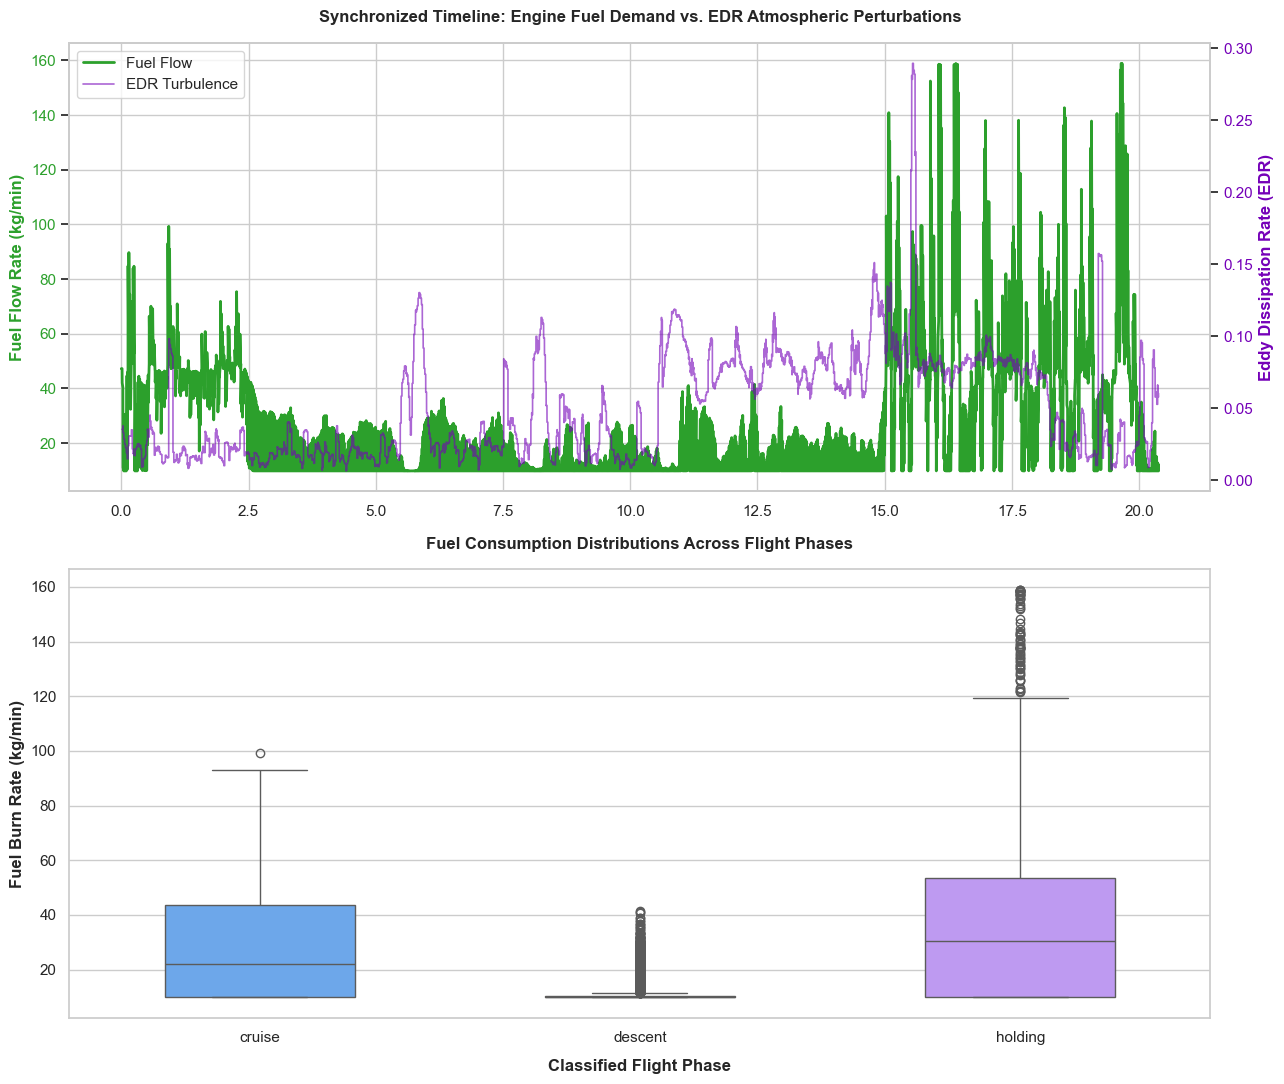

In [63]:
import pandas as pd
import numpy as np

def build_phase_and_mix_metrics(df_combined):
    """
    Safely calculates flight phases directly inside the active dataframe
    to prevent index alignment errors, then merges with turbulence metrics.
    """
    # Create a fresh working copy of your data
    df_metrics = df_combined.copy()
    
    # Extract arrays directly from this specific dataframe instance
    # (Matches whatever length df_metrics currently holds)
    alt_m = df_metrics['Height (m)'].values
    vel_ms = df_metrics['Velocity (m/s)'].values
    
    # Initialize the phase array with the exact matching length
    phase = np.full(len(df_metrics), 'descent', dtype=object)
    
    # Apply your exact logic rules
    # High cruise: >9,000m
    phase[alt_m > 9000] = 'cruise'
    
    # Holding/approach: ~5,300–5,600m, speed still high
    phase[(alt_m < 6000) & (vel_ms > 100)] = 'holding'
    
    # Final approach: slowing down below 6,000m
    phase[(alt_m < 6000) & (vel_ms <= 100)] = 'landing'
    
    # GPS glitch: single zero-velocity point at cruise altitude
    phase[(vel_ms < 5) & (alt_m > 1000)] = 'cruise'
    
    # Assign it back - since len(phase) == len(df_metrics), this will never throw an error
    df_metrics['Phase'] = phase
    
    # ----------------------------------------------------
    # Calculate EDR & Fuel Metrics on the same dataframe
    # ----------------------------------------------------
    if 'EDR' not in df_metrics.columns:
        df_metrics['g_force'] = df_metrics['Acceleration z (m/s^2)'] / 9.81
        # Rolling standard deviation over a 2-second window (20 samples at 10Hz)
        df_metrics['EDR'] = df_metrics['g_force'].rolling(window=20, min_periods=1).std() * 1.58
        
    df_metrics['Fuel_Flow_kg_min'] = df_metrics['Fuel_Flow_kg_s'] * 60
    
    # Generate the aggregate matrix printout
    summary = df_metrics.groupby('Phase').agg(
        avg_fuel_flow_kg_min=('Fuel_Flow_kg_min', 'mean'),
        total_fuel_burnt_kg=('Fuel_Burnt_Step_kg', 'sum'),
        avg_edr_intensity=('EDR', 'mean'),
        peak_edr_intensity=('EDR', 'max'),
        total_duration_sec=('dt', 'sum')
    ).reset_index()
    
    print("======================================================================")
    print("✈️ OPERATIONAL PROFILE: MIXED FUEL & TURBULENCE METRICS BY PHASE ✈️")
    print("======================================================================")
    print(summary.to_string(index=False, formatters={
        'avg_fuel_flow_kg_min': '{:,.2f} kg/min'.format,
        'total_fuel_burnt_kg': '{:,.1f} kg'.format,
        'avg_edr_intensity': '{:,.3f}'.format,
        'peak_edr_intensity': '{:,.3f}'.format,
        'total_duration_sec': '{:,.0f}s'.format
    }))
    print("======================================================================\n")
    
    # Trigger your visualization dashboards
    plot_mixed_fuel_turbulence_dashboard(df_metrics)
    
    return df_metrics, summary

# Run it by passing your primary processed DataFrame:
df_final, summary_df = build_phase_and_mix_metrics(output_df)